# Sistema de Recuperación de Información
## Examen Primer Bimestre
### Dataset Rotten Tomatoes

## Importación de librerías

In [75]:
#IMPORTACIONES#
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\juani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# CARGA DE CORPUS

In [76]:
#CARGA DE CORPUS#
movies_path = r"C:\Users\juani\OneDrive\Escritorio\Examen\rotten_tomatoes_movies.csv"
reviews_path = r"C:\Users\juani\OneDrive\Escritorio\Examen\rotten_tomatoes_critic_reviews.csv"

movies_df = pd.read_csv(movies_path)
reviews_df = pd.read_csv(reviews_path)

# UNIÓN DE DOCUMENTOS

In [77]:
#UNION DE DOCUMENTOS#
df = reviews_df.merge(
    movies_df,
    on="rotten_tomatoes_link",
    how="left"
)

# PREPROCESAMIENTO

In [78]:
stop_words = set(stopwords.words('english'))

from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

 #Lemmatizacion#
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    if pd.isna(text):
        return ""

    # minúsculas
    text = text.lower()

    # eliminar puntuación
    text = re.sub(r'[^\w\s]', ' ', text)

    # eliminar números
    text = re.sub(r'\d+', ' ', text)

    # eliminar espacios redundantes
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    # stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\juani\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# CREACIÓN DE UN DOCUMENTO TEXTUAL

In [79]:
df["document"] = (
    df["movie_title"].fillna('') + " " +
    df["review_content"].fillna('') + " " +
    df["review_type"].fillna('')
)

# APLICACIÓN DE PREPROCESAMIENTO

In [82]:
#APLICAR PREPROCESAMIENTO#
df["processed_text"] = df["document"].apply(preprocess_text)

## DADO QUE EL CORPUS ES ENORME SE TOMAN LOS PRIMEROS 8000 PARA EVITAR TIEMPO DE DEMORA Y UNA EJECUCIÓN RÁPIDA, SI SE GUSTA SE PUEDE CAMBIAR EL 8000 POR 35314 QUE ES EL TOTAL DE DOCUMENTOS DEL CORPUS

In [83]:
# tomar una muestra aleatoria
df = df.sample(8000, random_state=42)

# eliminar textos vacíos
df = df[df["processed_text"].str.strip() != ""]

# truncar textos muy largos
df["processed_text"] = df["processed_text"].str[:500]

# resetear índices
df = df.reset_index(drop=True)

# MODELO DE EMBEDDINGS A UTILIZAR

In [ ]:
#MODELO DE EMBEDDINGS#
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7434.15it/s]


# GENERACIÓN DE EMBEDDINGS

In [ ]:
#GENERAR EMBEDDINGS#
documents = df["processed_text"].tolist()

document_embeddings = model.encode(
    documents,
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches: 100%|██████████| 250/250 [00:27<00:00,  9.08it/s]


# GUARDA LOS EMBEDDINGS EN UN DOCUMENTO PARA NO GENERARLOS DE NUEVO (EN CASO DE SER NECESARIO)

In [ ]:
#GUARDA LOS EMBEDDINGS PARA NO CARGARLOS NUEVAMENTE DESDE 0#
np.save("document_embeddings.npy", document_embeddings)

# FUNCIÓN BÚSQUEDA, UTILIZANDO UN TOP K DE 5, SI SE DESEA VER MÁS DOCUMENTOS SE DEBERÁ CAMBIAR EL 5 POR LA CANTIDAD QUE SE GUSTE

In [ ]:
def search(query, top_k=5):

    # preprocesar consulta
    processed_query = preprocess_text(query)

    # generar embedding de consulta
    query_embedding = model.encode([processed_query])

    # calcular similitud coseno
    similarities = cosine_similarity(
        query_embedding,
        document_embeddings
    )[0]

    # obtener índices top-k
    top_indices = similarities.argsort()[-top_k:][::-1]

    results = []

    for rank, idx in enumerate(top_indices, start=1):

        results.append({
            "Ranking": rank,
            "Document_ID": df.iloc[idx]["rotten_tomatoes_link"],
            "Movie_Title": df.iloc[idx]["movie_title"],
            "Review": df.iloc[idx]["review_content"],
            "Similarity": round(similarities[idx], 4)
        })

    return pd.DataFrame(results)

# BÚSQUEDA POR TEXTO

In [ ]:
#BUSQUEDA POR TEXTO#
#Cambiar el valor de query por lo que se necesite buscar#

query = "kid playing with ball"

results = search(query, top_k=5)

results

,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/ball_of_fire,Ball of Fire,NaN,0.4389
1,2,m/toy_story_4,Toy Story 4,It's enough to make you feel like a kid again.,0.3499
2,3,m/cloudy_with_a_chance_of_meatballs_2_2013,Cloudy with a Chance of Meatballs 2,"It aims to entertain, to offer a few tame chuc...",0.3480
3,4,m/semi_pro,Semi-Pro,Step on up and see Ferrell shoot an air ball!,0.3400
4,5,m/playing_for_keeps_2012,Playing for Keeps,"Gabriele Muccino's film is knee-deep in ""don't...",0.3254


# QUERIES INDICADAS EN EL DOCUMENTO

In [ ]:
#QUERIES#
queries = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences"
}

# EJECUCIÓN AUTOMÁTICA DE CONSULTAS

In [ ]:
#EJECUTA LAS CONSULTAS#
summary_results = []

for query_id, query_text in queries.items():

    print("="*80)
    print(f"{query_id}: {query_text}")
    print("="*80)

    results = search(query_text, top_k=5)

    display(results)

    top1 = results.iloc[0]

    summary_results.append({
        "Query": query_id,
        "Top_Document": top1["Document_ID"],
        "Movie_Title": top1["Movie_Title"],
        "Similarity": top1["Similarity"]
    })

Q1: science fiction movie with advanced technology


,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/star_wars_episode_ii_attack_of_the_clones,Star Wars: Episode II - Attack of the Clones,"It's an ambitious film, and as with all ambiti...",0.4923
1,2,m/back_to_the_future,Back to the Future,Back to the Future is one of the best popcorn ...,0.4696
2,3,m/catch_that_kid,Catch That Kid,More absorbingly character-driven and less tec...,0.4625
3,4,m/bee_movie,Bee Movie,"While never as clever as it thinks it is, and ...",0.4576
4,5,m/the_pact_2012,The Pact,More horror movies set in the 21st century oug...,0.4566


Q2: romantic story with emotional relationships


,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/once,Once,...a unique twist on the musical with this aff...,0.6033
1,2,m/love_is_all_you_need,Love Is All You Need,At the heart of this formulaic bore is the pot...,0.5881
2,3,m/marriage_story_2019,Marriage Story,Marriage Story is a timeless look at relations...,0.5819
3,4,m/marriage_story_2019,Marriage Story,This haunting portrait of a marriage falling a...,0.5733
4,5,m/eternal_sunshine_of_the_spotless_mind,Eternal Sunshine of the Spotless Mind,"Eternal Sunshine is fresh, heartfelt and ultim...",0.5567


Q3: action movie with intense fight scenes


...

,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/namesake,The Namesake,"A very emotionally powerful, moving film.",0.5260
1,2,m/take_the_lead,Take the Lead,Hugely entertaining.,0.5181
2,3,m/alex_of_venice,Alex of Venice,Messina channels a history of performance into...,0.5061
3,4,m/sully,Sully,Despite its excellent lead performance from To...,0.4913
4,5,m/the_hole_in_the_ground,The Hole in the Ground,"Kerslake is a magnetic lead actor, incredibly ...",0.4898


Q7: predictable plot but entertaining experience


,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/approaching_the_unknown,Approaching the Unknown,Too high-minded to ever stoop to suspense or f...,0.5885
1,2,m/unforgivable_2012,Unforgivable,Unforgivable is a bit too relaxed to function ...,0.5580
2,3,m/daddys_home_2014,Daddy's Home,Consider it a predictable movie with flashes o...,0.5527
3,4,m/how_do_you_know,How Do You Know,It feels less like a coherent narrative than a...,0.5508
4,5,m/split_2017,Split,The biggest surprise here isn't the premise it...,0.5465


Q8: movie praised by critics but unpopular with audiences


,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/click,Click,The film's overall problem is that it asks tho...,0.5472
1,2,m/united_93,United 93,No film and no subject are above criticism: Un...,0.5360
2,3,m/1142569-cursed,Cursed,Horror audiences should come to realize that H...,0.5184
3,4,m/triple_9,Triple 9,the kind of terrible movie that can only be ma...,0.5111
4,5,m/fanboys,Fanboys,"Nothing more than an attempt to stroke the ""St...",0.5044


# TABLA DE RESUMEN GENERAL

In [ ]:
#TABLA DE RESUMEN GENERAL#
summary_df = pd.DataFrame(summary_results)

# ordenar de mayor a menor similitud
summary_df = summary_df.sort_values(
    by="Similarity",
    ascending=False
).reset_index(drop=True)

summary_df

,Query,Top_Document,Movie_Title,Similarity
0,Q4,m/scream-4,Scream 4,0.6591
1,Q2,m/once,Once,0.6033
2,Q7,m/approaching_the_unknown,Approaching the Unknown,0.5885
3,Q5,m/pacific_rim_2013,Pacific Rim,0.5876
4,Q3,m/showdown_in_little_tokyo_1998,Showdown in Little Tokyo,0.5779
5,Q8,m/click,Click,0.5472
6,Q6,m/namesake,The Namesake,0.5260
7,Q1,m/star_wars_episode_ii_attack_of_the_clones,Star Wars: Episode II - Attack of the Clones,0.4923


# VISUALIZACIÓN PCA

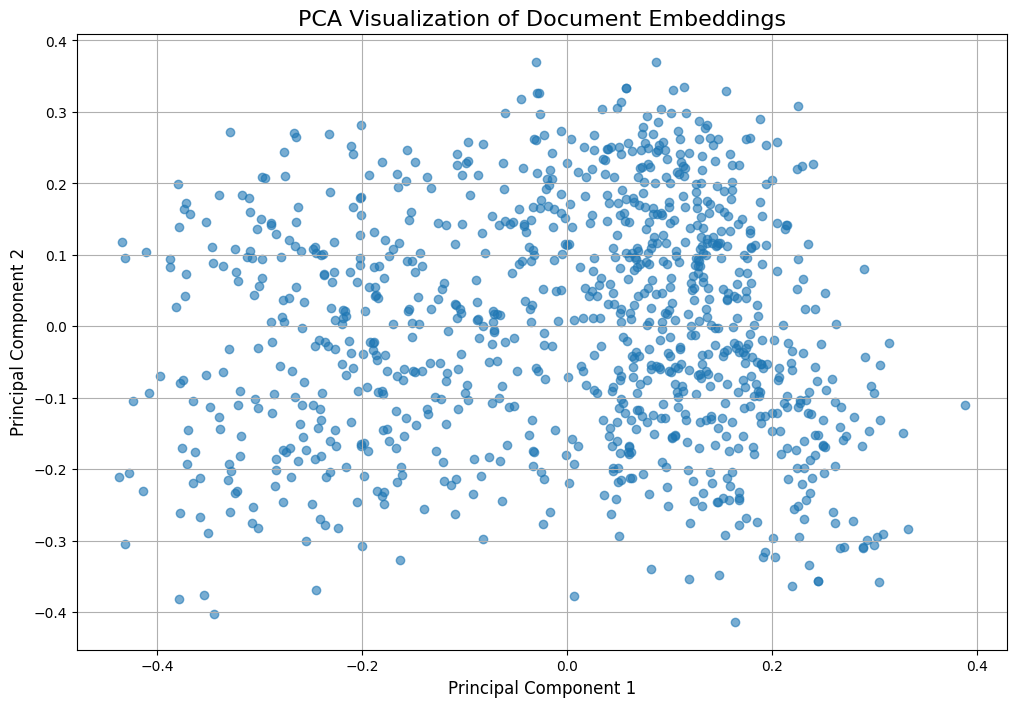

In [ ]:
# tomar muestra de embeddings
sample_size = 1000

sample_indices = np.random.choice(
    len(document_embeddings),
    sample_size,
    replace=False
)

sample_embeddings = document_embeddings[sample_indices]

# PCA
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(sample_embeddings)

# gráfico
plt.figure(figsize=(12,8))

plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1],
    alpha=0.6
)

plt.title(
    "PCA Visualization of Document Embeddings",
    fontsize=16
)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.grid(True)

plt.show()

# COMPARACIÓN DE 2 MODELOS (ADICIONAL)

In [ ]:
#Comparacion de 2 modelos
#Modelo actual all-MiniLM-L6-v2
#2do modelo paraphrase-MiniLM-L3-v2

# CARGA DEL MODELO 2 A USAR

In [ ]:
#Cargar modelo
model_2 = SentenceTransformer(
    'paraphrase-MiniLM-L3-v2'
)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 6617.14it/s]


# GENERACIÓN DE EMBEDDING MODELO 2

In [ ]:
#Generar embeddings
document_embeddings_2 = model_2.encode(
    documents,
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches: 100%|██████████| 250/250 [00:15<00:00, 16.41it/s]


# FUNCIÓN DE BÚSQUEDA MODELO 2

In [ ]:
#NUEVA FUNCIÓN DE BUSQUEDA
def search_model_2(query, top_k=5):

    processed_query = preprocess_text(query)

    query_embedding = model_2.encode([processed_query])

    similarities = cosine_similarity(
        query_embedding,
        document_embeddings_2
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = []

    for rank, idx in enumerate(top_indices, start=1):

        results.append({
            "Ranking": rank,
            "Movie_Title": df.iloc[idx]["movie_title"],
            "Similarity": round(similarities[idx], 4)
        })

    return pd.DataFrame(results)

# COMPARACIÓN DE 2 MODELOS

In [ ]:

query = "science fiction movie with advanced technology"

print("RESULTADOS MODELO 1")
display(search(query))

print("\nRESULTADOS MODELO 2")
display(search_model_2(query))

RESULTADOS MODELO 1


,Ranking,Document_ID,Movie_Title,Review,Similarity
0,1,m/star_wars_episode_ii_attack_of_the_clones,Star Wars: Episode II - Attack of the Clones,"It's an ambitious film, and as with all ambiti...",0.4923
1,2,m/back_to_the_future,Back to the Future,Back to the Future is one of the best popcorn ...,0.4696
2,3,m/catch_that_kid,Catch That Kid,More absorbingly character-driven and less tec...,0.4625
3,4,m/bee_movie,Bee Movie,"While never as clever as it thinks it is, and ...",0.4576
4,5,m/the_pact_2012,The Pact,More horror movies set in the 21st century oug...,0.4566



RESULTADOS MODELO 2


,Ranking,Movie_Title,Similarity
0,1,Realive,0.5364
1,2,American Made,0.5353
2,3,Project Almanac,0.5256
3,4,Battleship,0.5211
4,5,Oblivion,0.5127


# COMPARACIÓN DE MODELOS PCA (ADICIONAL)

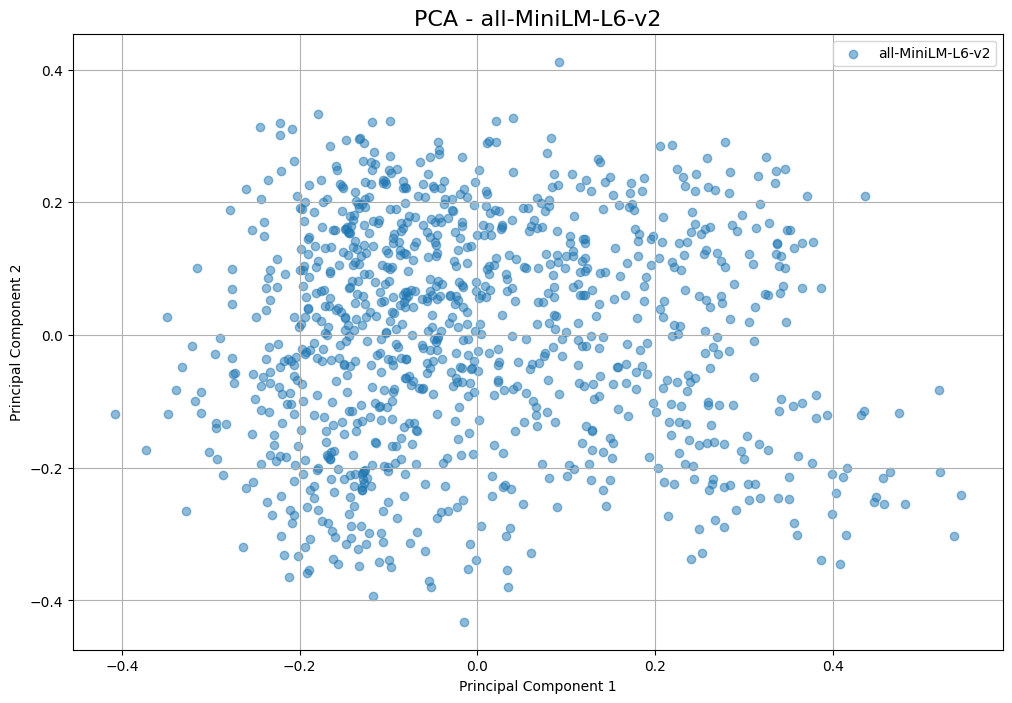

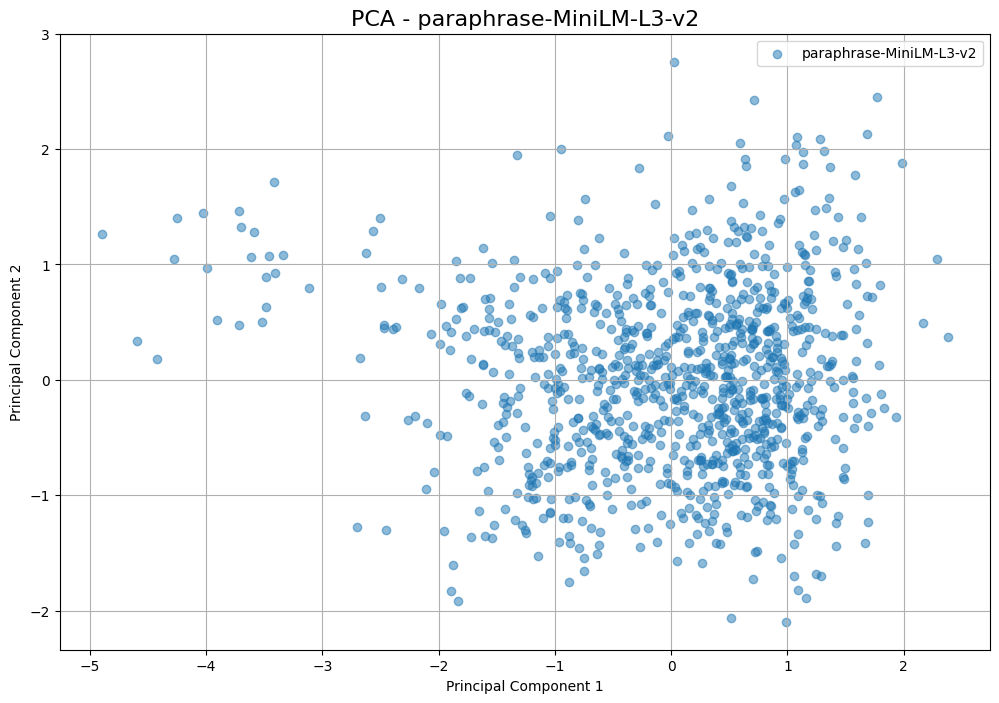

In [ ]:
# muestra aleatoria
sample_size = 1000

sample_indices = np.random.choice(
    len(document_embeddings),
    sample_size,
    replace=False
)

# embeddings modelo 1
sample_embeddings_1 = document_embeddings[sample_indices]

# embeddings modelo 2
sample_embeddings_2 = document_embeddings_2[sample_indices]

# PCA modelo 1
pca_1 = PCA(n_components=2)

reduced_1 = pca_1.fit_transform(sample_embeddings_1)

# PCA modelo 2
pca_2 = PCA(n_components=2)

reduced_2 = pca_2.fit_transform(sample_embeddings_2)

# gráfico modelo 1
plt.figure(figsize=(12,8))

plt.scatter(
    reduced_1[:,0],
    reduced_1[:,1],
    alpha=0.5,
    label='all-MiniLM-L6-v2'
)

plt.title(
    "PCA - all-MiniLM-L6-v2",
    fontsize=16
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.legend()

plt.show()

# gráfico modelo 2
plt.figure(figsize=(12,8))

plt.scatter(
    reduced_2[:,0],
    reduced_2[:,1],
    alpha=0.5,
    label='paraphrase-MiniLM-L3-v2'
)

plt.title(
    "PCA - paraphrase-MiniLM-L3-v2",
    fontsize=16
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.legend()

plt.show()